## Лабораторная работа №2
### Компьютерное зрение

**Выполнил:** Изгородин Илья Юрьевич  
**Группа:** ФИТ-232  
**Факультет:** ФИТиКС ОмГТУ  

*Омск, 2026*

## Подготовка окружения

Перед началом выполнения работы устанавливаю и импотрирую библиотеки, необходимые для поставленных заданий

In [99]:
!pip install matplotlib==3.10.8 numpy==2.4.2 opencv-python==4.13.0.92 opencv-contrib-python==4.13.0.92

������ ������� ��࠭��: 1251


In [100]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

Функция для удобного отображения изображений (заимствовано с 1 ЛР)

In [101]:
def imsh(img, is_gray=False):
    fig = plt.figure(frameon=False)
    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)
    ax.imshow(img, cmap='gray' if is_gray else None)
    plt.show()

Загружаю тестовое изображение

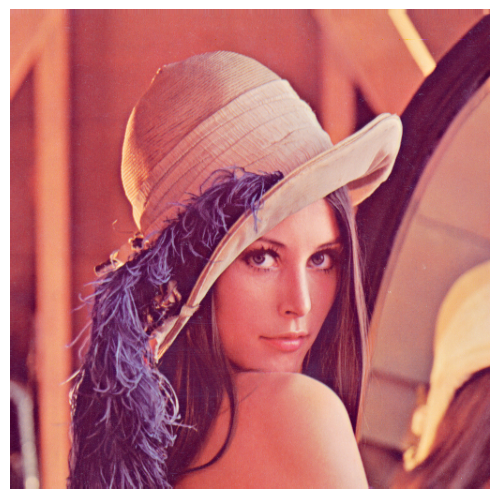

In [102]:
img = cv2.cvtColor(cv2.imread("Lenna.png"), cv2.COLOR_BGR2RGB)
imsh(img)

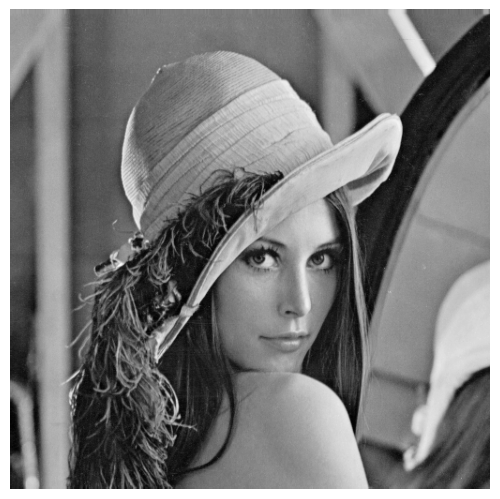

In [103]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
imsh(img_gray, True)

# Задание 1 Изменение размера изображения

Для проверки результатов выполнения функций создаю уменьшенное изображение, которое будет увеличиваться функциями

In [104]:
img_small = cv2.resize(img, (0, 0), fx=0.1, fy=0.1, interpolation=cv2.INTER_NEAREST)

Реализую функцию увеличения методом ближайшего соседа

In [105]:
def resize_nn(img, size_factor):
    h, w = img.shape[:2]
    new_h, new_w = int(h * size_factor), int(w * size_factor)
    
    if len(img.shape) == 3:
        new_img = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)
    else:
        new_img = np.zeros((new_h, new_w), dtype=img.dtype)
    
    for i in range(new_h):
        for j in range(new_w):
            old_i = int(i * h / new_h)
            old_j = int(j * w / new_w)
            old_i = min(old_i, h-1)
            old_j = min(old_j, w-1)
            new_img[i, j] = img[old_i, old_j]
    
    return new_img

In [106]:
img_nn = resize_nn(img_small, 10)

Реализую функцию увеличения методом билинейной интерполяции

In [107]:
def resize_bilinear(img, size_factor):
    h, w = img.shape[:2]
    new_h, new_w = int(h * size_factor), int(w * size_factor)
    
    if len(img.shape) == 3:
        new_img = np.zeros((new_h, new_w, img.shape[2]), dtype=np.float32)
        channels = img.shape[2]
    else:
        new_img = np.zeros((new_h, new_w), dtype=np.float32)
        channels = 1
    
    for i in range(new_h):
        for j in range(new_w):
            x = j / size_factor
            y = i / size_factor
            
            x1, y1 = int(np.floor(x)), int(np.floor(y))
            x2, y2 = min(x1 + 1, w - 1), min(y1 + 1, h - 1)
            
            dx = x - x1
            dy = y - y1
            
            for c in range(channels):
                top = img[y1, x1, c] * (1 - dx) + img[y1, x2, c] * dx
                bottom = img[y2, x1, c] * (1 - dx) + img[y2, x2, c] * dx
                new_img[i, j, c] = top * (1 - dy) + bottom * dy

    new_img = cv2.normalize(new_img, None, 0, 255, cv2.NORM_MINMAX)
    return new_img.astype(np.uint8)

In [108]:
img_bi = resize_bilinear(img_small, 10)

Отображаю результаты увеличения, проверяя `len`, чтобы убедиться, что изображения поменяли размер

51


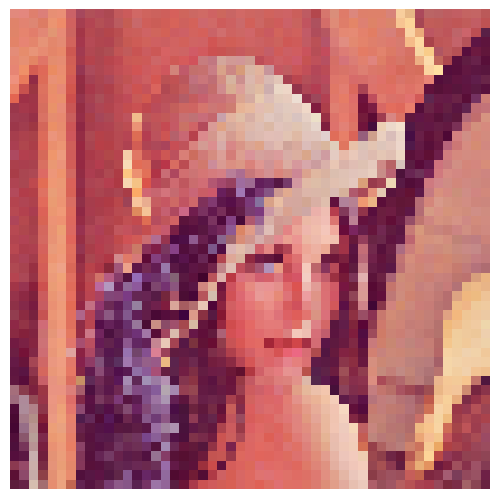

510


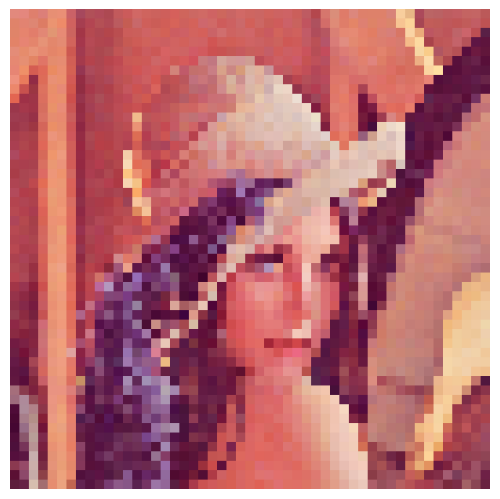

510


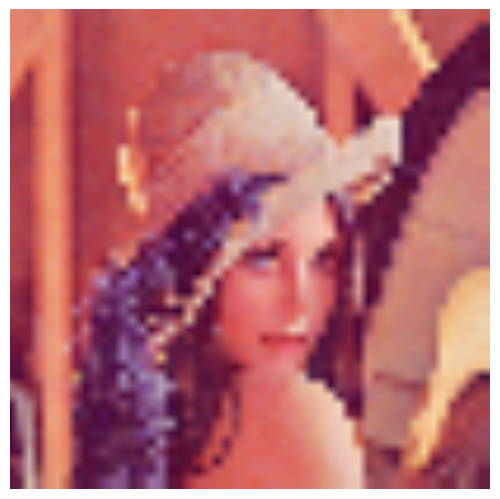

In [109]:
for i in [img_small, img_nn, img_bi]:
    print(len(i))
    imsh(i)

# Задание 2 Сжатие изображения

Реализую функцию сжатия методом прореживания

In [110]:
def downsample_1(img, size_factor):
    if size_factor >= 1:
        raise ValueError("size_factor должен быть меньше 1")
    
    h, w = img.shape[:2]
    new_h = int(h * size_factor)
    new_w = int(w * size_factor)
    
    if len(img.shape) == 3:
        new_img = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)
    else:
        new_img = np.zeros((new_h, new_w), dtype=img.dtype)
    
    step = int(1 / size_factor)
    
    for i in range(new_h):
        for j in range(new_w):
            old_i = i * step
            old_j = j * step
            new_img[i, j] = img[old_i, old_j]
    
    return new_img

Реализую функцию сжатия методом усреднения

In [111]:
def downsample_2(img, size_factor):
    if size_factor >= 1:
        raise ValueError("size_factor должен быть меньше 1")
    
    h, w = img.shape[:2]
    new_h = int(h * size_factor)
    new_w = int(w * size_factor)
    
    block_h = h // new_h
    block_w = w // new_w
    
    if len(img.shape) == 3:
        new_img = np.zeros((new_h, new_w, img.shape[2]), dtype=np.float32)
        channels = img.shape[2]
    else:
        new_img = np.zeros((new_h, new_w), dtype=np.float32)
        channels = 1
    
    for i in range(new_h):
        for j in range(new_w):
            y_start = i * block_h
            y_end = (i + 1) * block_h
            x_start = j * block_w
            x_end = (j + 1) * block_w
            
            if channels == 1:
                block = img[y_start:y_end, x_start:x_end]
                new_img[i, j] = np.mean(block)
            else:
                for c in range(channels):
                    block = img[y_start:y_end, x_start:x_end, c]
                    new_img[i, j, c] = np.mean(block)
    
    return np.clip(new_img, 0, 255).astype(np.uint8)

In [112]:
img_down1 = downsample_1(img, 0.2)
img_down2 = downsample_2(img, 0.2)

Отображаю результаты сжатия

102


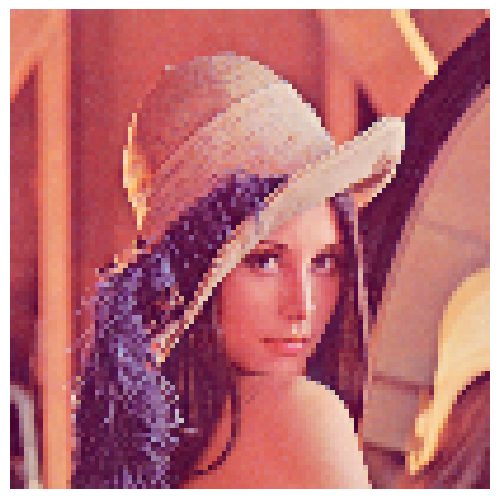

102


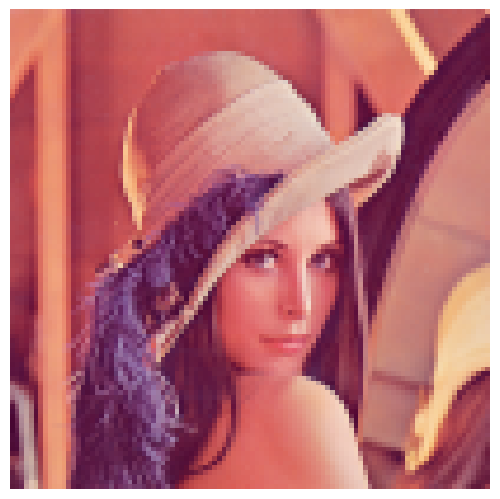

In [113]:
for i in [img_down1, img_down2]:
    print(len(i))
    imsh(i)

# Задание 3 Линейная трансформация гистограммы

Реализую функцию линейной трансформации гистограммы

In [114]:
def linear_hist_transform(img, percent=0.05):
    img_float = img.astype(np.float32)
    
    y_min = np.percentile(img_float, percent * 100)
    y_max = np.percentile(img_float, 100 - percent * 100)
    
    img_norm = 255 * (img_float - y_min) / (y_max - y_min)
    img_result = np.clip(img_norm, 0, 255).astype(np.uint8)
    
    return img_result, (y_min, y_max)

In [115]:
img_linear, (y_min, y_max) = linear_hist_transform(img_gray, percent=0.05)

Отображаю результаты линейной трансформации

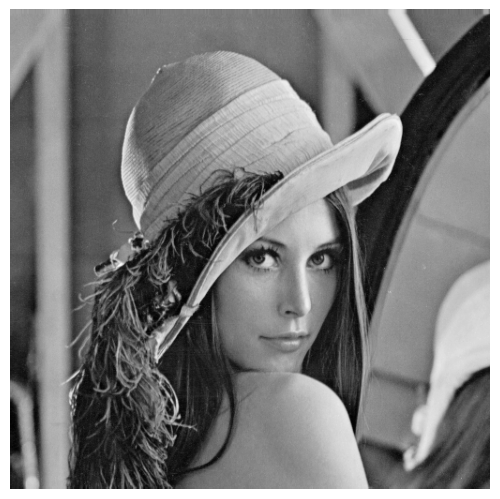

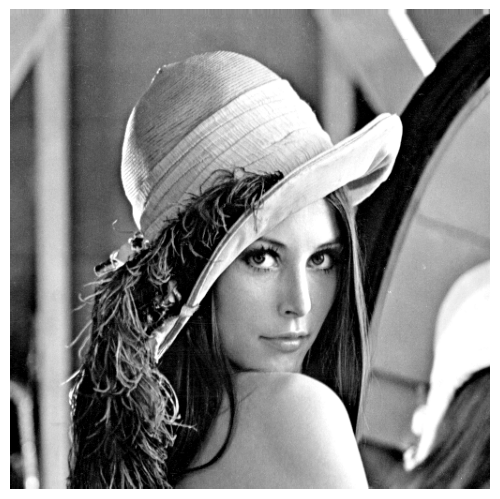

In [116]:
imsh(img_gray, True)
imsh(img_linear, True)

Для проверки корректности функции вывожу гистограммы

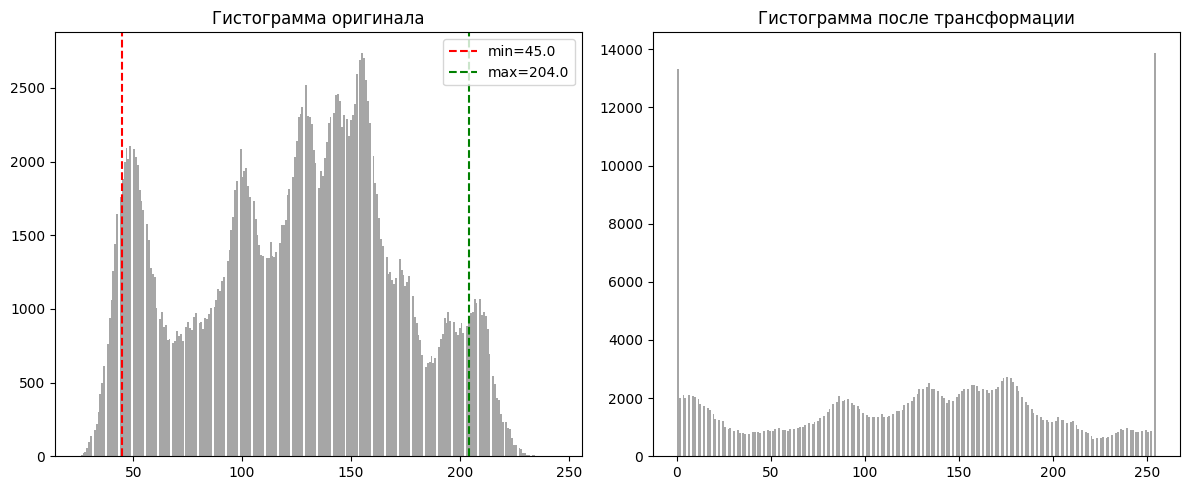

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(img_gray.ravel(), bins=256, color='gray', alpha=0.7)
axes[0].set_title('Гистограмма оригинала')
axes[0].axvline(y_min, color='red', linestyle='--', label=f'min={y_min:.1f}')
axes[0].axvline(y_max, color='green', linestyle='--', label=f'max={y_max:.1f}')
axes[0].legend()

axes[1].hist(img_linear.ravel(), bins=256, color='gray', alpha=0.7)
axes[1].set_title('Гистограмма после трансформации')

plt.tight_layout()
plt.show()

# Задание 4 Гамма коррекция

Реализую функцию гамма коррекции

In [118]:
def gamma_transform(img, gamma):
    img_norm = img.astype(np.float32) / 255.0
    img_gamma = np.power(img_norm, gamma)
    return np.clip(img_gamma * 255, 0, 255).astype(np.uint8)

Вывожу результаты выполнения функции и гистограммы получившихся изображений

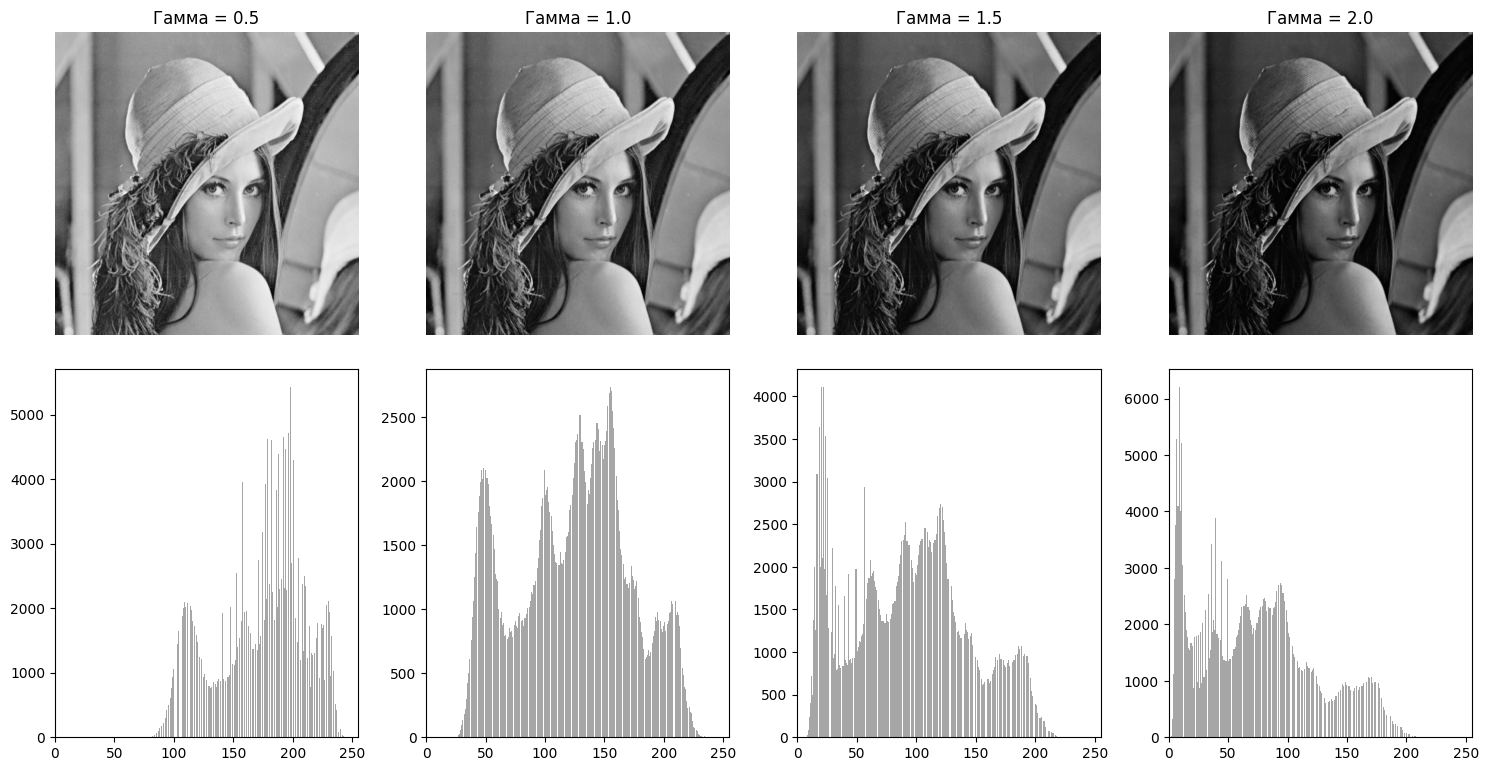

In [119]:
gammas = [0.5, 1.0, 1.5, 2.0]
images_gamma = [gamma_transform(img_gray, g) for g in gammas]

fig, axes = plt.subplots(2, len(gammas), figsize=(15, 8))
for i, (g, img_g) in enumerate(zip(gammas, images_gamma)):
    axes[0, i].imshow(img_g, cmap='gray')
    axes[0, i].set_title(f'Гамма = {g}')
    axes[0, i].axis('off')
    axes[1, i].hist(img_g.ravel(), bins=256, color='gray', alpha=0.7)
    axes[1, i].set_xlim(0, 255)

plt.tight_layout()
plt.show()

# Задание 5 Эквализация гистограммы

Загружаю тестовое изображение

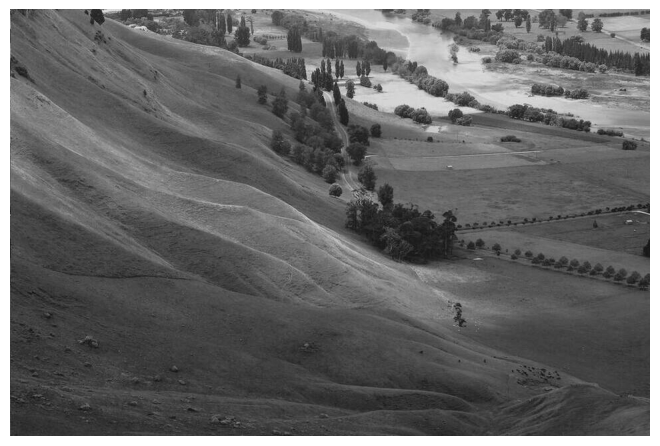

In [120]:
img_heq = cv2.cvtColor(cv2.imread("Unequalized_Hawkes_Bay_NZ.jpg"), cv2.COLOR_BGR2GRAY)
imsh(img_heq, True)

Реализую функцию стандартизации гистограммы

In [121]:
def hist_eq(img):
    h, w = img.shape
    total_pixels = h * w
    
    hist = np.zeros(256, dtype=np.float32)
    for i in range(h):
        for j in range(w):
            hist[img[i, j]] += 1
    
    cdf = np.zeros(256, dtype=np.float32)
    cdf[0] = hist[0] / total_pixels
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i] / total_pixels
    
    transform = np.floor(255 * cdf).astype(np.uint8)
    
    img_eq = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            img_eq[i, j] = transform[img[i, j]]
    
    return img_eq, transform

Вывожу результат выполнения функции и гистограммы (обычная и кумулятивная)

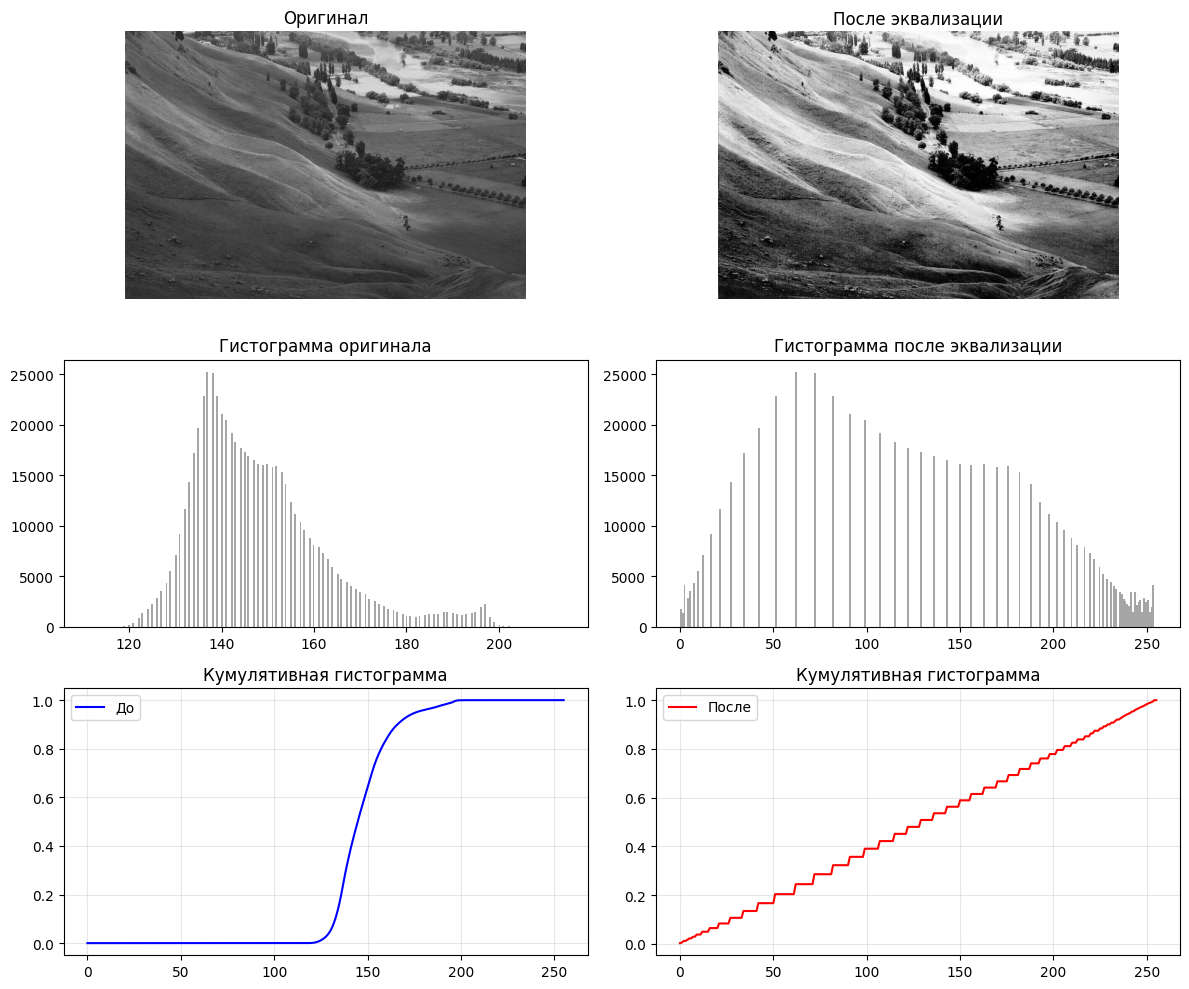

In [122]:
img_eq, transform = hist_eq(img_heq)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes[0, 0].imshow(img_heq, cmap='gray')
axes[0, 0].set_title('Оригинал')
axes[0, 0].axis('off')
axes[0, 1].imshow(img_eq, cmap='gray')
axes[0, 1].set_title('После эквализации')
axes[0, 1].axis('off')

axes[1, 0].hist(img_heq.ravel(), bins=256, color='gray', alpha=0.7)
axes[1, 0].set_title('Гистограмма оригинала')
axes[1, 1].hist(img_eq.ravel(), bins=256, color='gray', alpha=0.7)
axes[1, 1].set_title('Гистограмма после эквализации')

hist_orig, _ = np.histogram(img_heq.ravel(), bins=256, range=(0, 256))
cdf_orig = hist_orig.cumsum() / hist_orig.sum()
hist_eq_vals, _ = np.histogram(img_eq.ravel(), bins=256, range=(0, 256))
cdf_eq = hist_eq_vals.cumsum() / hist_eq_vals.sum()

axes[2, 0].plot(cdf_orig, 'b-', label='До')
axes[2, 0].set_title('Кумулятивная гистограмма')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)
axes[2, 1].plot(cdf_eq, 'r-', label='После')
axes[2, 1].set_title('Кумулятивная гистограмма')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()